In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import numpy as np
import matplotlib.pyplot as plt
import cv2

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.16.2


In [3]:
# Load CIFAR-10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

# Simple but good enough CNN for CIFAR-10
def build_cifar_model():
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
        Conv2D(32, (3,3), activation='relu'),
        MaxPooling2D((2,2)),
        Dropout(0.25),
        
        Conv2D(64, (3,3), activation='relu', padding='same'),
        Conv2D(64, (3,3), activation='relu'),
        MaxPooling2D((2,2)),
        Dropout(0.25),
        
        Flatten(),
        Dense(512, activation='relu'),
        Dropout(0.5),
        Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

cifar_model = build_cifar_model()
cifar_model.fit(x_train, y_train, epochs=15, batch_size=64, validation_data=(x_test, y_test), verbose=1)

/home/saidul/Desktop/4-2/Deep Learning/myenv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


/home/saidul/Desktop/4-2/Deep Learning/myenv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15


/home/saidul/Desktop/4-2/Deep Learning/myenv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15


2026-05-09 19:59:46.216259: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 614400000 exceeds 10% of free system memory.


782/782 ━━━━━━━━━━━━━━━━━━━━ 117s 144ms/step - accuracy: 0.4327 - loss: 1.5533 - val_accuracy: 0.5826 - val_loss: 1.1826
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 114s 145ms/step - accuracy: 0.5931 - loss: 1.1501 - val_accuracy: 0.6468 - val_loss: 1.0049
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 110s 141ms/step - accuracy: 0.6469 - loss: 0.9946 - val_accuracy: 0.6923 - val_loss: 0.8702
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 109s 139ms/step - accuracy: 0.6847 - loss: 0.8962 - val_accuracy: 0.7153 - val_loss: 0.8068
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 106s 135ms/step - accuracy: 0.7117 - loss: 0.8235 - val_accuracy: 0.7280 - val_loss: 0.7812
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 114s 146ms/step - accuracy: 0.7291 - loss: 0.7696 - val_accuracy: 0.7385 - val_loss: 0.7564
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 110s 141ms/step - accuracy: 0.7401 - loss: 0.7347 - val_accuracy: 0.7458 - val_loss: 0.7261
Epoch 8/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 108s 138ms/step - accuracy: 0.7549 - loss: 0.69

In [14]:
# Check layer names
for layer in cifar_model.layers:
    if 'conv' in layer.name:
        print(layer.name)

conv2d
conv2d_1
conv2d_2
conv2d_3


In [40]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # 1. Dynamically get the input shape from the model
    # model.input_shape is usually (None, 64, 64, 3)
    input_shape = model.input_shape[1:] 
    inputs = tf.keras.Input(shape=input_shape)
    
    # 2. Re-route through layers (Dynamic rebuilding)
    x = inputs
    target_layer_output = None
    for layer in model.layers:
        x = layer(x)
        if layer.name == last_conv_layer_name:
            target_layer_output = x
            
    # 3. Create the gradient model
    grad_model = tf.keras.Model(inputs, [target_layer_output, x])

    # 4. GradientTape logic
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    # 5. Generate heatmap
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    
    # Normalize
    heatmap = np.maximum(heatmap, 0) / (np.max(heatmap) + 1e-10)
    return heatmap.numpy() if hasattr(heatmap, "numpy") else heatmap


In [45]:
cifar_class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                     'dog', 'frog', 'horse', 'ship', 'truck']

last_conv_layer = "conv2d_3"   # Confirmed from your list

In [46]:
def show_explainability(model, img, true_label, last_conv_layer_name):
    img_array = np.expand_dims(img, axis=0)
    
    # Get prediction
    preds = model.predict(img_array, verbose=0)
    pred_class = np.argmax(preds[0])
    
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.imshow(img)
    plt.title(f"Original\nTrue: {true_label}\nPred: {cifar_class_names[pred_class]}")
    plt.axis('off')
    
    # Generate heatmap
    heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=pred_class)
    heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    
    plt.subplot(1, 3, 2)
    plt.imshow(heatmap_resized, cmap='jet')
    plt.title("Grad-CAM Heatmap")
    plt.axis('off')
    
    # Superimposed
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    # Convert image to 0-255 uint8 for OpenCV
    img_255 = np.uint8(255 * img) if img.max() <= 1.0 else np.uint8(img)
    superimposed = cv2.addWeighted(img_255, 0.6, heatmap_colored, 0.4, 0)

    
    plt.subplot(1, 3, 3)
    plt.imshow(superimposed)
    plt.title("Superimposed")
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

Generating Grad-CAM explanations for CIFAR-10...


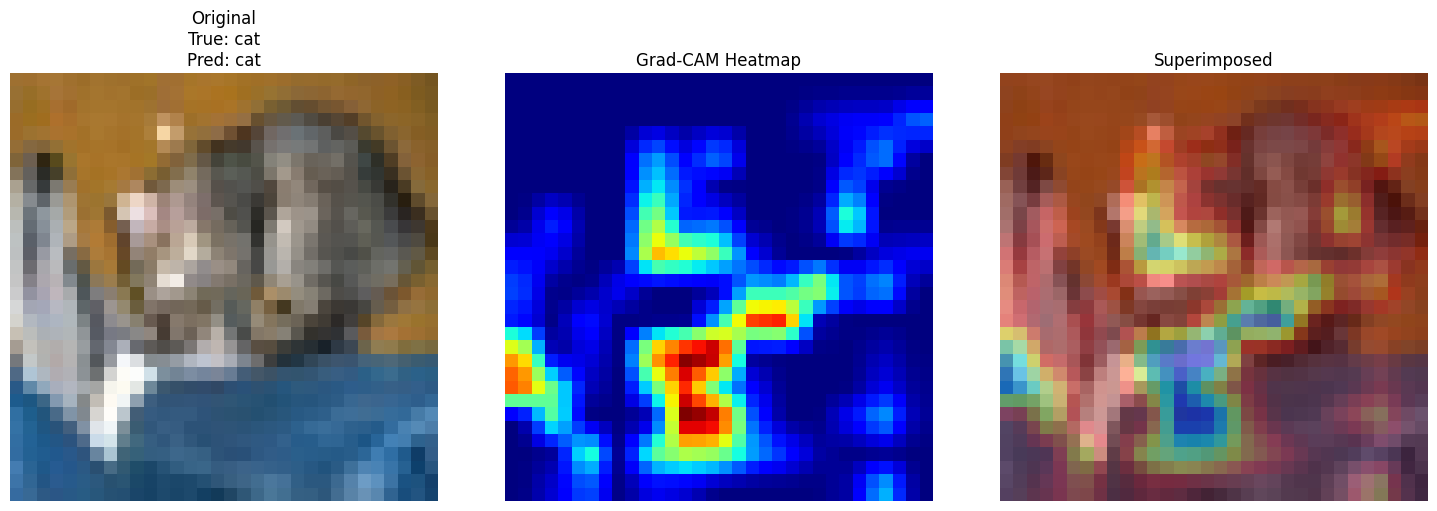

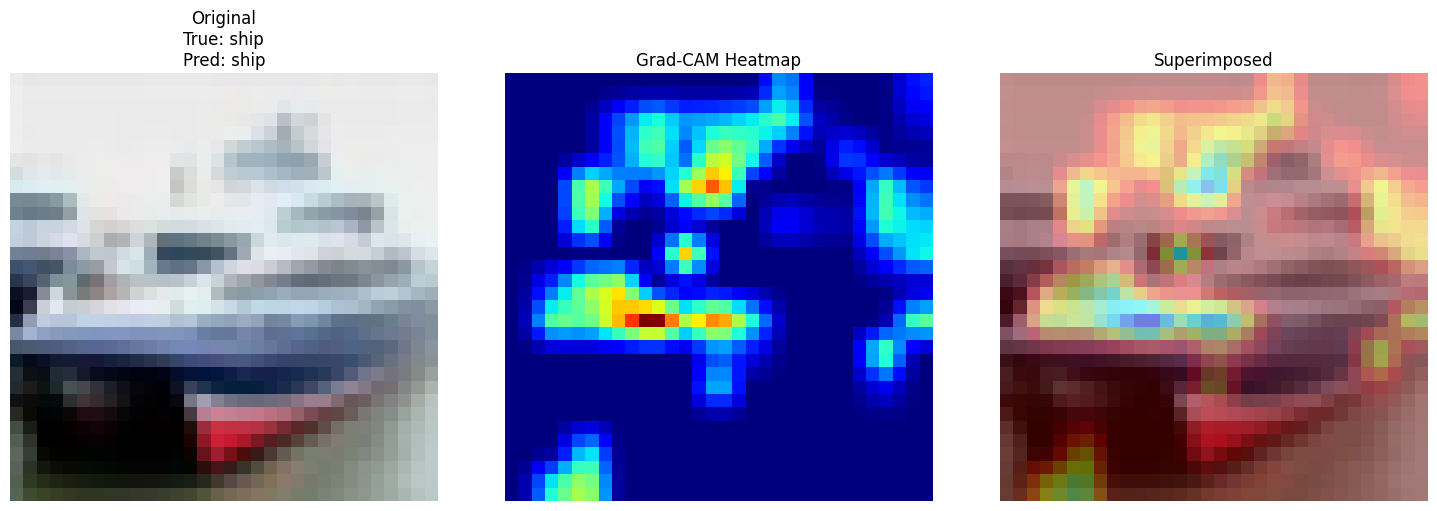

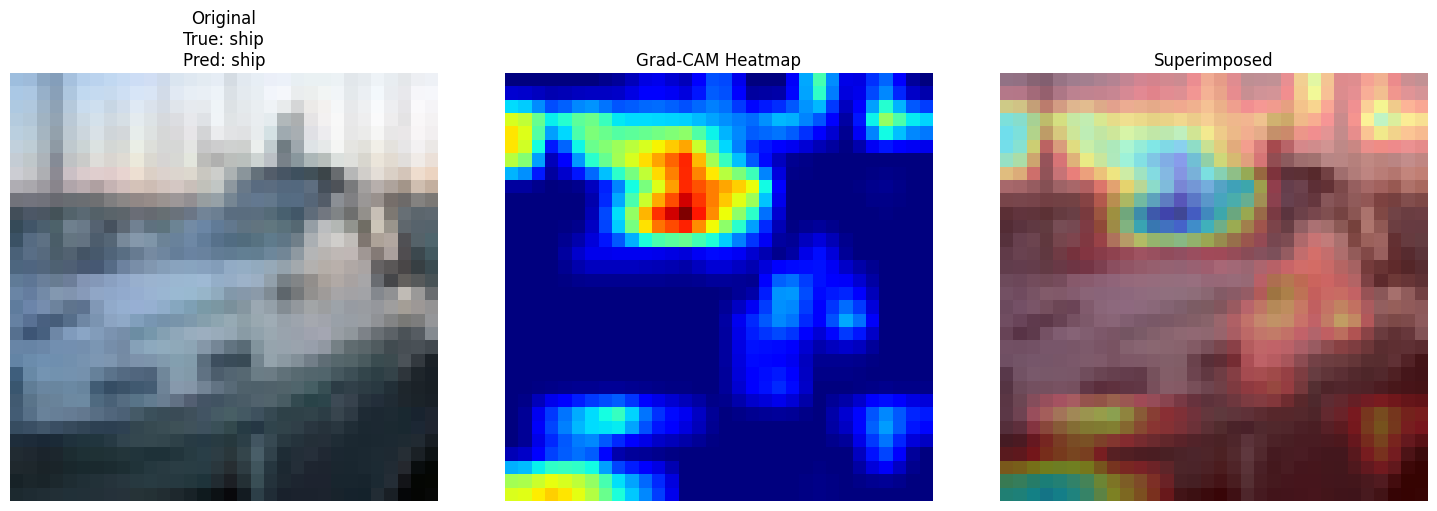

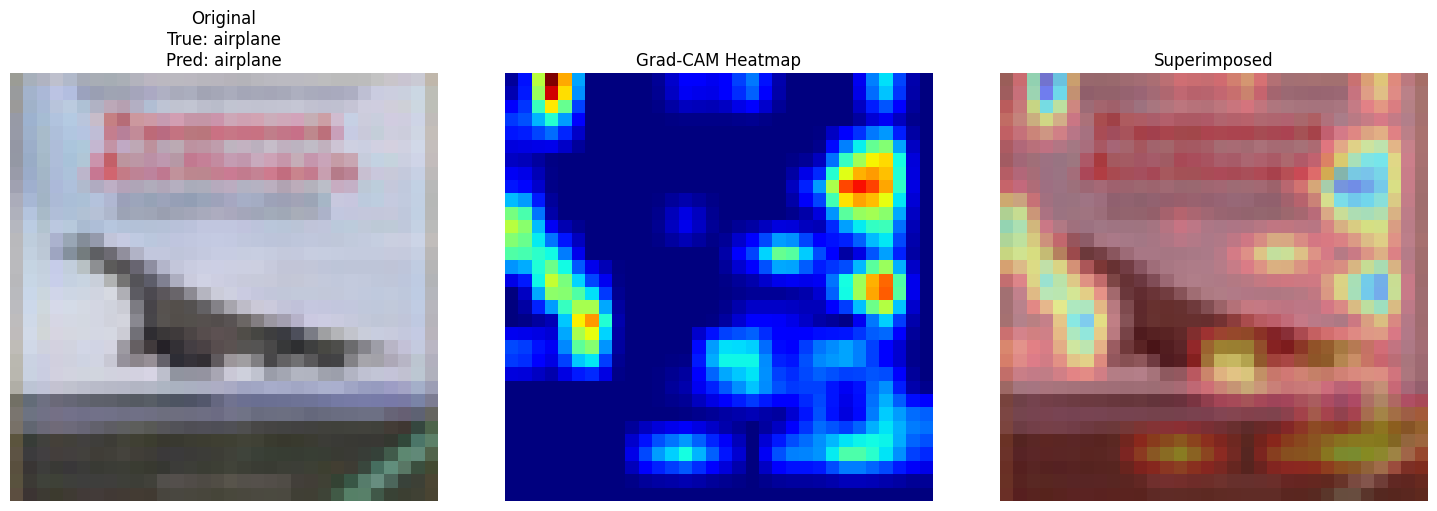

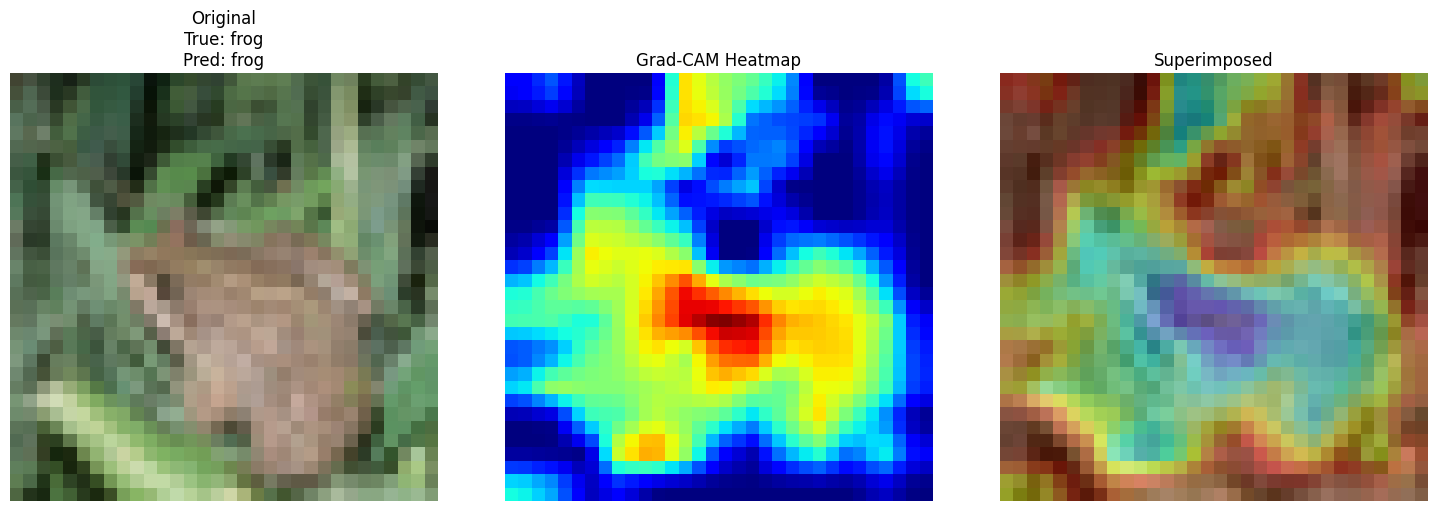

In [47]:

print("Generating Grad-CAM explanations for CIFAR-10...")

for i in range(5):
    show_explainability(cifar_model, x_test[i],
                        cifar_class_names[np.argmax(y_test[i])],
                        last_conv_layer_name=last_conv_layer)

In [43]:
# Load your face dataset (same structure as previous assignments)
# Assume you have folder: ../data/faces/ with subfolders person_0, person_1, ..., person_6

from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = train_datagen.flow_from_directory(
    '/home/saidul/Desktop/4-2/Deep Learning/data/faces',
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical',
    subset='training')

val_generator = train_datagen.flow_from_directory(
    '/home/saidul/Desktop/4-2/Deep Learning/data/faces',
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical',
    subset='validation')

# Build simple face classifier
face_model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(train_generator.num_classes, activation='softmax')
])

face_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
face_model.fit(train_generator, epochs=10, validation_data=val_generator)

Found 28 images belonging to 7 classes.
Found 7 images belonging to 7 classes.
Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.2500 - loss: 1.9576 - val_accuracy: 0.1429 - val_loss: 1.9196
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 413ms/step - accuracy: 0.1786 - loss: 1.9064 - val_accuracy: 0.1429 - val_loss: 1.8629
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step - accuracy: 0.2143 - loss: 1.8099 - val_accuracy: 0.5714 - val_loss: 1.7940
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step - accuracy: 0.3214 - loss: 1.8309 - val_accuracy: 0.7143 - val_loss: 1.7104
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.3571 - loss: 1.8076 - val_accuracy: 0.8571 - val_loss: 1.6427
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step - accuracy: 0.4286 - loss: 1.6479 - val_accuracy: 0.5714 - val_loss: 1.5642
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step - accuracy: 0.4286 - loss: 1.5329 - val_accuracy: 0.5714 - val_loss: 1.4512
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 266

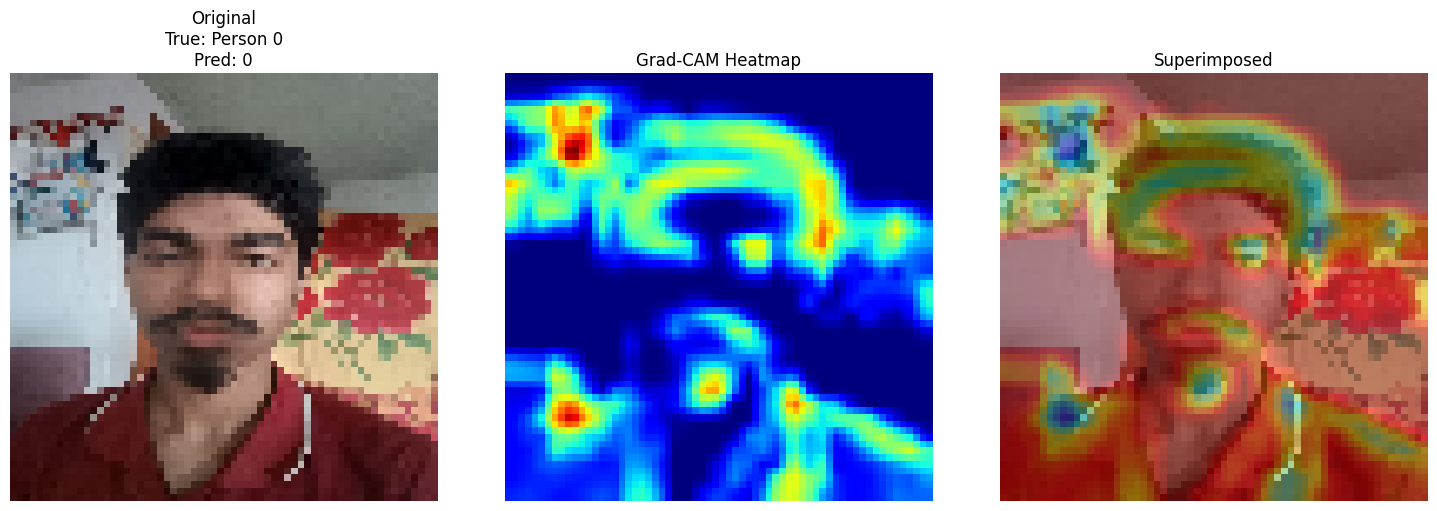

In [44]:
# Test on one of your face images
test_img_path = '/home/saidul/Desktop/4-2/Deep Learning/data/faces/person_0/Saidul_0.jpg'   # Change path
test_img = tf.keras.preprocessing.image.load_img(test_img_path, target_size=(64,64))
test_array = tf.keras.preprocessing.image.img_to_array(test_img) / 255.0

show_explainability(face_model, test_array, 
                   f"Person {np.argmax(face_model.predict(np.expand_dims(test_array,0), verbose=0))}",
                   last_conv_layer_name="conv2d_8")   # Update layer name after face_model.summary()